# FIR 滤波器设计：窗函数法与等波纹法

本文介绍两种经典的 FIR 滤波器设计方法：

1. **窗函数法**（Window Method）：直觉清晰，快速上手
2. **等波纹法**（Equiripple / Parks-McClellan）：更精确，工程中常用

---

## 1. FIR 滤波器的基本思路

FIR（有限冲激响应）滤波器的输出是输入信号与一组系数 $h[n]$ 的卷积：

$$y[n] = \sum_{k=0}^{N-1} h[k]\, x[n-k]$$

设计滤波器，本质上就是**找到一组系数 $h[n]$**，使其频率响应 $H(e^{j\omega})$ 满足我们的需求（比如低通、带通等）。

理想低通滤波器的频率响应为矩形：

$$H_d(e^{j\omega}) = \begin{cases} 1 & |\omega| \leq \omega_c \\ 0 & |\omega| > \omega_c \end{cases}$$

对应的时域冲激响应（IDTFT）是一个 **sinc 函数**：

$$h_d[n] = \frac{\omega_c}{\pi} \text{sinc}\!\left(\frac{\omega_c}{\pi} n\right) = \frac{\sin(\omega_c n)}{\pi n}$$

> 问题：$h_d[n]$ 是双边无限长序列，无法直接实现。

---
## 2. 窗函数法：Sinc + Hamming 窗

### 2.1 设计步骤

**核心思路**：将无限长的 $h_d[n]$ 截断并加窗，得到有限长的近似。

$$h[n] = h_d[n] \cdot w[n], \quad n = 0, 1, \ldots, N-1$$

其中 $w[n]$ 是窗函数，$N$ 是滤波器阶数（tap 数）。

**Hamming 窗**定义为：

$$w[n] = 0.54 - 0.46\cos\!\left(\frac{2\pi n}{N-1}\right), \quad 0 \leq n \leq N-1$$

/tmp/ipykernel_1616/1372930198.py:16: RuntimeWarning: invalid value encountered in divide
  np.sin(wc * (n - M)) / (np.pi * (n - M)))


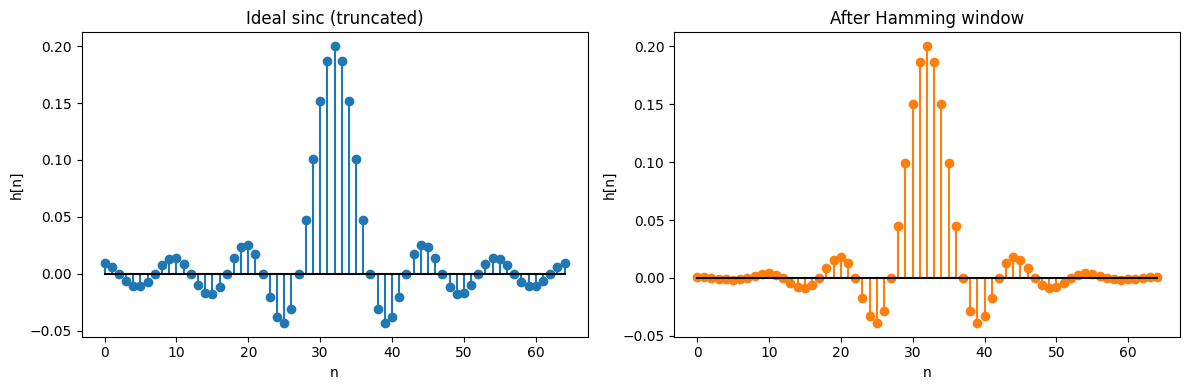

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Parameters ---
fs = 1000.0   # sample rate (Hz)
fc = 100.0    # cutoff frequency (Hz)
N  = 65       # filter length (odd -> symmetric linear phase)
wc = 2 * np.pi * fc / fs   # normalized cutoff (rad/sample)

# --- Ideal sinc coefficients (centered at (N-1)/2) ---
M = (N - 1) // 2
n = np.arange(N)
h_ideal = np.where(n == M,
                   wc / np.pi,
                   np.sin(wc * (n - M)) / (np.pi * (n - M)))

# --- Multiply by Hamming window ---
w_hamming = np.hamming(N)
h_win = h_ideal * w_hamming

# --- Plot: truncated sinc vs windowed coefficients ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(n, h_ideal, linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[0].set_title('Ideal sinc (truncated)')
axes[0].set_xlabel('n'); axes[0].set_ylabel('h[n]')

axes[1].stem(n, h_win, linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1].set_title('After Hamming window')
axes[1].set_xlabel('n'); axes[1].set_ylabel('h[n]')

plt.tight_layout()
plt.show()


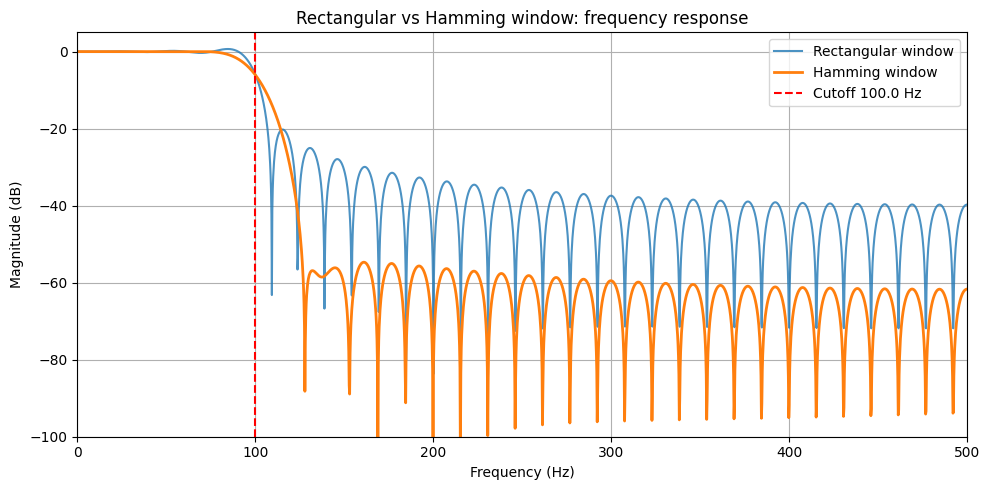

In [2]:
# --- Frequency response: rectangular window vs Hamming window ---
NFFT = 2048
h_rect = h_ideal * np.ones(N)   # rectangular = plain truncation

freq, H_rect = signal.freqz(h_rect, worN=NFFT, fs=fs)
freq, H_win  = signal.freqz(h_win,  worN=NFFT, fs=fs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq, 20*np.log10(np.abs(H_rect) + 1e-10), label='Rectangular window', alpha=0.8)
ax.plot(freq, 20*np.log10(np.abs(H_win)  + 1e-10), label='Hamming window', lw=2)
ax.axvline(fc, color='r', linestyle='--', label=f'Cutoff {fc} Hz')
ax.set_xlim(0, fs/2)
ax.set_ylim(-100, 5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('Rectangular vs Hamming window: frequency response')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


---
## 3. 为什么这样设计是有效的？

### 3.1 频域角度：乘法 → 卷积

时域乘以窗函数，等价于**频域与窗函数的频谱做卷积**：

$$H(e^{j\omega}) = H_d(e^{j\omega}) * W(e^{j\omega})$$

这个卷积会把理想矩形频谱的边缘「平滑」掉：窗越宽（频域越窄），过渡带越陡；窗的旁瓣越低，阻带衰减越大。

### 3.2 Gibbs 现象

直接用矩形窗截断会产生 **Gibbs 现象**：截止频率附近出现约 9% 的过冲，且无论增大 $N$，过冲幅度不会消失（约 −21 dB 阻带衰减）。

Hamming 窗通过**渐变的边缘**削弱不连续点的影响，将阻带衰减提升到约 −41 dB。

### 3.3 常用窗函数对比

| 窗函数      | 旁瓣峰值 (dB) | 最小阻带衰减 (dB) | 过渡带宽（× $2\pi/N$） |
|------------|:------------:|:----------------:|:--------------------:|
| 矩形窗      | −13          | −21              | 0.9                  |
| Hanning 窗 | −31          | −44              | 3.1                  |
| **Hamming 窗** | **−41**  | **−41**          | **3.3**              |
| Blackman 窗 | −57         | −74              | 5.5                  |
| Kaiser 窗  | 可调         | 可调              | 可调                 |

> **结论**：窗函数法简单直观，但阻带衰减和过渡带宽**不能独立控制**，只能靠选窗和增大 $N$ 来折衷。

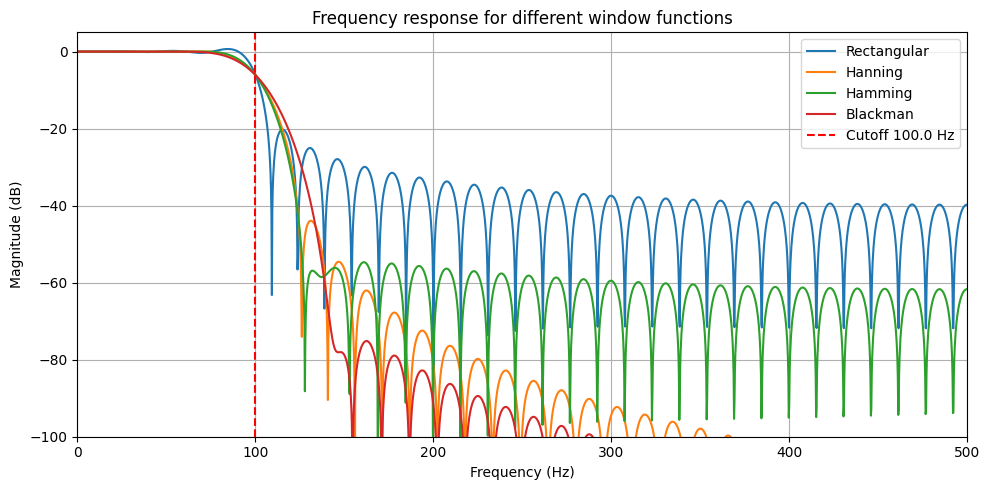

In [3]:
# --- Compare several window functions ---
windows = {
    'Rectangular': np.ones(N),
    'Hanning':     np.hanning(N),
    'Hamming':     np.hamming(N),
    'Blackman':    np.blackman(N),
}

fig, ax = plt.subplots(figsize=(10, 5))
for name, w in windows.items():
    h = h_ideal * w
    f, H = signal.freqz(h, worN=NFFT, fs=fs)
    ax.plot(f, 20*np.log10(np.abs(H) + 1e-10), label=name)

ax.axvline(fc, color='r', linestyle='--', label=f'Cutoff {fc} Hz')
ax.set_xlim(0, fs/2); ax.set_ylim(-100, 5)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
ax.set_title('Frequency response for different window functions')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()


---
## 4. 进阶：等波纹设计法（Parks-McClellan）

### 4.1 窗函数法的局限

窗函数法的本质是**截断**，因此：
- 过渡带形状不可精确指定
- 通带/阻带的波纹分布不均匀，有的地方浪费了「误差预算」

**等波纹法**的出发点：在满足阶数 $N$ 的前提下，让**最坏情况的逼近误差最小化**，即 minimax 最优化：

$$\min_{h} \max_{\omega} \left| W(\omega)\bigl[H_d(e^{j\omega}) - H(e^{j\omega})\bigr] \right|$$

其中 $W(\omega)$ 是加权函数，用来控制通带/阻带的相对误差要求。

### 4.2 Chebyshev 等波纹与 Remez 交换算法

根据 **Chebyshev 逼近理论**，最优解存在且唯一，其误差曲线在极值点处**等幅交替正负**——这正是「等波纹」名称的来源。

**Parks-McClellan 算法**（Remez 交换算法的应用）通过迭代找到这组等波纹极值点：

1. 猜测一组极值点 $\{\omega_k\}$（共 $N/2 + 2$ 个）
2. 在这些点上求解线性方程组，得到最优系数和误差幅值 $\delta$
3. 在整个频段上搜索新的极值点（误差最大处）
4. 替换极值点集合，重复 2-3 直到收敛

收敛后，通带波纹 $\delta_1$ 和阻带波纹 $\delta_2$ 满足比例关系 $\delta_1/\delta_2 = W_{stop}/W_{pass}$（由加权函数决定）。

### 4.3 Python 实现（`scipy.signal.remez`）

Python 的 `scipy.signal.remez` 对应 MATLAB 的 `firpm`（旧版为 `remez`）。

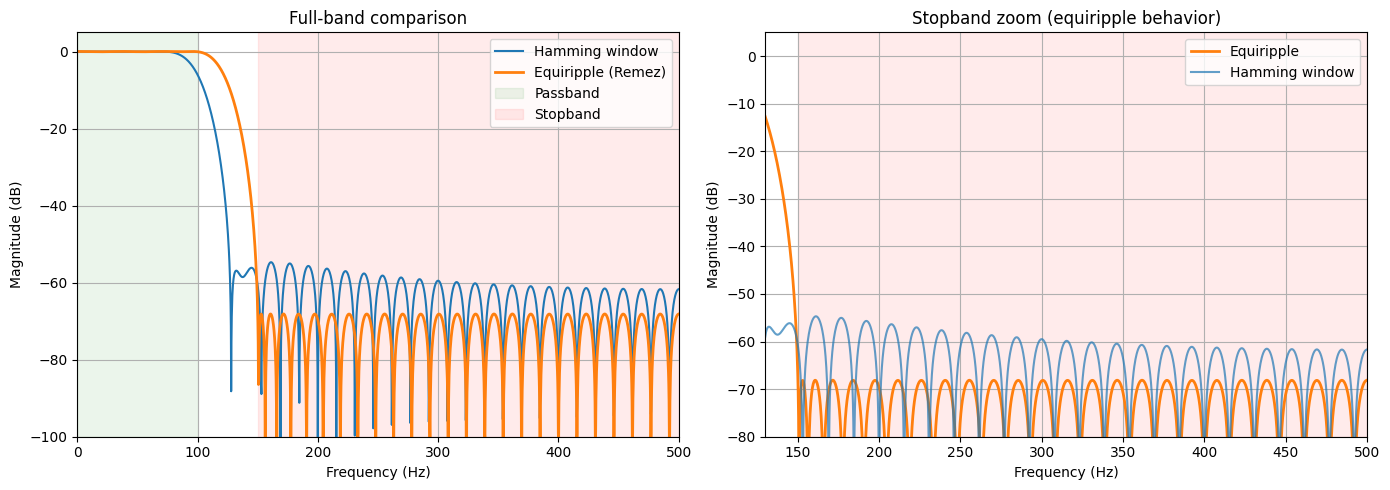

In [4]:
# --- Equiripple lowpass filter design (Parks-McClellan / Remez) ---
# Spec:
#   passband 0 ~ 100 Hz,  stopband 150 ~ 500 Hz
#   stopband weight = 10x passband (tighter stopband ripple)

f_pass = 100.0   # passband edge (Hz)
f_stop = 150.0   # stopband edge (Hz)
N_eq   = 65      # same length as window method for fair comparison

h_eq = signal.remez(
    N_eq,
    bands   = [0, f_pass, f_stop, fs/2],
    desired = [1, 0],
    weight  = [1, 10],
    fs      = fs
)

freq_eq, H_eq = signal.freqz(h_eq, worN=NFFT, fs=fs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full-band comparison
axes[0].plot(freq,    20*np.log10(np.abs(H_win) + 1e-10), label='Hamming window')
axes[0].plot(freq_eq, 20*np.log10(np.abs(H_eq)  + 1e-10), label='Equiripple (Remez)', lw=2)
axes[0].axvspan(0,      f_pass, alpha=0.08, color='green', label='Passband')
axes[0].axvspan(f_stop, fs/2,   alpha=0.08, color='red',   label='Stopband')
axes[0].set_xlim(0, fs/2); axes[0].set_ylim(-100, 5)
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Full-band comparison')
axes[0].legend(); axes[0].grid(True)

# Zoom into stopband to see equiripple behavior
axes[1].plot(freq_eq, 20*np.log10(np.abs(H_eq) + 1e-10), 'C1', lw=2, label='Equiripple')
axes[1].plot(freq,    20*np.log10(np.abs(H_win) + 1e-10), 'C0', alpha=0.7, label='Hamming window')
axes[1].axvspan(f_stop, fs/2, alpha=0.08, color='red')
axes[1].set_xlim(f_stop - 20, fs/2); axes[1].set_ylim(-80, 5)
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('Stopband zoom (equiripple behavior)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


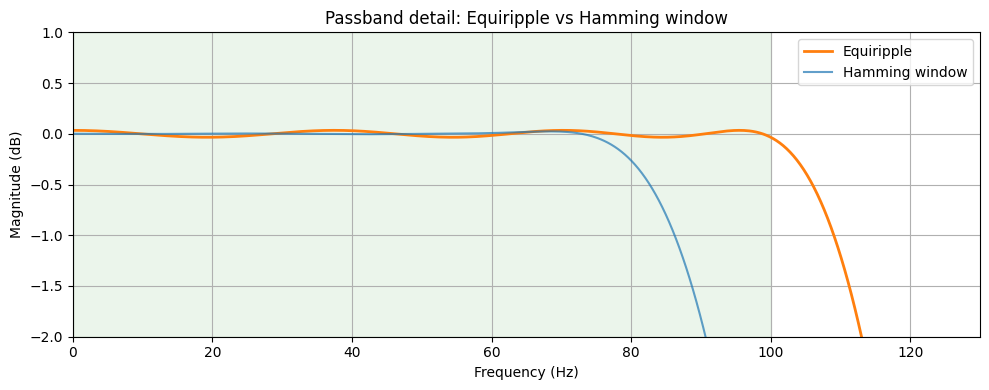

=== Hamming window ===
Passband (0-100 Hz)           max=0.02 dB  min=-5.92 dB  ripple=5.95 dB
Stopband (150-500 Hz)         max=-54.69 dB  min=-117.26 dB  ripple=62.58 dB

=== Equiripple (Remez) ===
Passband (0-100 Hz)           max=0.03 dB  min=-0.03 dB  ripple=0.07 dB
Stopband (150-500 Hz)         max=-68.12 dB  min=-137.51 dB  ripple=69.39 dB


In [5]:
# --- Passband zoom: equiripple vs Hamming ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freq_eq, 20*np.log10(np.abs(H_eq) + 1e-10), 'C1', lw=2, label='Equiripple')
ax.plot(freq,    20*np.log10(np.abs(H_win) + 1e-10), 'C0', alpha=0.7, label='Hamming window')
ax.axvspan(0, f_pass, alpha=0.08, color='green')
ax.set_xlim(0, f_pass + 30); ax.set_ylim(-2, 1)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
ax.set_title('Passband detail: Equiripple vs Hamming window')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

# --- Key metrics ---
def band_stats(H, f, f_lo, f_hi, label):
    mask = (f >= f_lo) & (f <= f_hi)
    mag_db = 20 * np.log10(np.abs(H[mask]) + 1e-10)
    print(f"{label:28s}  max={mag_db.max():.2f} dB  min={mag_db.min():.2f} dB  "
          f"ripple={mag_db.max()-mag_db.min():.2f} dB")

print("=== Hamming window ===")
band_stats(H_win, freq, 0, f_pass, "Passband (0-100 Hz)")
band_stats(H_win, freq, f_stop, fs/2, "Stopband (150-500 Hz)")
print("\n=== Equiripple (Remez) ===")
band_stats(H_eq, freq_eq, 0, f_pass, "Passband (0-100 Hz)")
band_stats(H_eq, freq_eq, f_stop, fs/2, "Stopband (150-500 Hz)")


---
## 5. 两种方法的本质对比

| 维度           | 窗函数法                          | 等波纹法（Parks-McClellan）         |
|--------------|:--------------------------------:|:----------------------------------:|
| 设计思路       | 截断理想 sinc，加窗平滑            | minimax 最优逼近                    |
| 理论基础       | Fourier 级数截断 + 窗函数卷积      | Chebyshev 多项式逼近 + Remez 迭代   |
| 规格指定       | 只能给截止频率和阶数               | 可独立指定通带/阻带/过渡带 + 权重    |
| 通带/阻带波纹  | 不均匀，通带接近 0 波纹但阻带不等  | 通带与阻带内波纹等幅（最优）         |
| 计算复杂度     | O(N)                             | 迭代算法，但对实际使用可忽略         |
| 对应 MATLAB   | `fir1(N, Wn, window)`            | `firpm(N, f, a, w)`（旧版 `remez`）|
| 对应 Python   | `signal.firwin` / 手动 sinc×窗   | `signal.remez`                     |

### 什么时候用哪个？

- 快速原型 / 对指标要求不严格 → **窗函数法**，一行代码搞定
- 需要精确控制通带波纹、阻带衰减、过渡带宽 → **等波纹法**
- 需要最短滤波器长度满足给定指标 → 等波纹法（同等指标下通常比窗函数法节省 20-30% 的 tap 数）

---
## 6. 小结

```
理想矩形频谱
  → IDTFT → 无限长 sinc
      → 截断 + 加窗 → 窗函数法 FIR   (简单，够用)
      → minimax 最优化 → 等波纹法 FIR  (精确，工程首选)
```

两者都是**线性相位 FIR**，群延迟为常数 $(N-1)/2$，不存在相位失真，这是相比 IIR 的核心优势。